In [172]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

# Dynamics of fields in a Fabry-Perot cavity

The dynamics are described by the difference equation (Rakhmanov Eq. 1.50):

$E(t) = t_a E_\mathrm{in}(t) + r_a r_b e^{-2 i k d(t)} E(t-2T)$

where:
* $t_a$ is the transmissivity of the input mirror;
* $E_\mathrm{in}(t)$ is input laser field;
* $r_a$ and $r_b$ are the reflectivities of the mirrors (a - input, b - output);
* $k = \omega / c = 2\pi / \lambda$ is the wavenumber;
* $d(t) = L + x_b(t-T) - x_a(t) = L + \xi$ is physical length of the cavity (Rakhmanov Eq. 1.33);
* $T = \frac{L}{c}$ is half of the round-trip time;
* $L$ is half of the round-trip;
* $E(t-2T)$ is the field inside the cavity at the time before one round-trip.

## Finesse and cavity decay time

Coefficient of finesse:

$F = \frac{4 r_a r_b}{(1 - r_a r_b)^2}$

$\tau_s = \frac{FL}{c\pi}$

Finesse ($\mathcal{F}$) of the cavity:

$\mathcal{F} = \frac{\pi}{2} \sqrt{F}$

Approximately: $\mathcal{F} = \pi N_\mathrm{eff}$

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [173]:
class cavity():
    def __init__(self, t_a=0.001, r_a=0.99, r_b=0.999, L=3000.0):
        self.t_a = t_a
        self.r_a = r_a
        self.r_b = r_b
        self.L = L  # m
        self.T = L/const.c  # s

    def cavity_loss(self):
        Loss = 1. - np.power(self.t_a,2) - np.power(self.r_a,2)
        
        if  Loss < 0.:
            print("Attenti ai valori")
        else:
            print("Loss: {0}".format(Loss))
    
        return Loss

    def N_eff(self):
        '''
        Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
        '''
        return int(np.round(1./np.abs(np.log(self.r_a * self.r_b))))

    def F(self):
        '''
        Coefficient of finesse
        '''
        return 4.*self.r_a*self.r_b / np.power(1.-self.r_a*self.r_b, 2)
    
    def tau_s(self):
        '''
        Formula equivalent to Eq. 2.17 (Rakhmanov)
    
        return 2. * T * N_eff(r_a, r_b)
        '''
        return self.F() * self.L / (np.pi * const.c)
    
    def Finesse(self):
        '''
        Finesse
        '''
        return np.sqrt(self.F()) * np.pi / 2.

    def tau(self):
        return 2. * self.T * self.N_eff()

    def gain(self):
        return self.t_a / (1. - self.r_a*self.r_b)

    def print_params(self):
        print("Coefficient of finesse: {0:.2f}".format(self.F()))
        print("Half round-trip time: {0:.2e} [s]".format(self.T))
        print("Effective number of photon round trip: {0:d}".format(self.N_eff()))
        print("Tau_s: {0:.2e} [s]".format(self.tau_s()))
        print("Finesse: {0:.2f}".format(self.Finesse()))
        print("Gain: {0:.2f}".format(self.gain()))

In [174]:
# LASER
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2*np.pi / lambd

## Cavity parameters summary

### ARM cavity

In [175]:
L = np.ceil(3000.0/lambd)*lambd - 0.05*lambd

ARM = cavity(t_a = 0.001, r_a = 0.99, r_b = 0.999, L = L)
ARM.print_params()

Coefficient of finesse: 32754.07
Half round-trip time: 1.00e-05 [s]
Effective number of photon round trip: 90
Tau_s: 1.04e-01 [s]
Finesse: 284.28
Gain: 0.09


### Filter cavity

In [176]:
L = np.ceil(284.9/lambd)*lambd - 0.05*lambd
FC = cavity(t_a = 0.000562, r_a = 0.9998398, r_b = 0.99983999, L = L)

'''
# Finesse 9582-10204  # Thermal detuning of a bichromatic narrow linewidth optical cavity L.D. BONAVENA
t_a = 0.000562
t_b = 0.00000316  # Thermal detuning of a bichromatic narrow linewidth optical cavity L.D. BONAVENA
r_a = np.sqrt(1. - t_a**2)-0.00016
r_b = np.sqrt(1. - t_b**2)-0.00016
L = 284.9  # m
'''

FC.print_params()

Coefficient of finesse: 39005034.74
Half round-trip time: 9.50e-07 [s]
Effective number of photon round trip: 3123
Tau_s: 1.18e+01 [s]
Finesse: 9810.25
Gain: 1.76


## Critical velocity

$v_\mathrm{cr} = \frac{\lambda}{2\tau\mathcal{F}}$

where $\tau$ is the storage time:

$\tau = 2 T N_\mathrm{eff}$

In [177]:
def v_cr(cavity):
    return lambd / (2. * cavity.Finesse() * cavity.tau())  # In [m/s]!

In [178]:
v_cr(ARM)

1.0389294414660628e-06

In [179]:
v_cr(FC)

9.136033732953133e-09

## Airy function

In [180]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

# Cavity state sampling

This section is dedicated to the data acquisition which collects available information about the cavity such as: reflected optical power, trasmitted optical power and Pound-Drever-Hall error signal.

For efficient data treatment we consider placing the data into rolling buffers. Our first estimation of the buffer length is based on the cavity storage time $\tau$ and the sampling rate.

* sampling rate
* sampling interval
* useful past samples - considering the fact that the cavity storage time is known, there exists a maximum number of past samples usefull in the state estimation

Attempt for an efficient python circular buffer implementation:

    import collections
    d = collections.deque(maxlen=10)

    deque([], maxlen=10)
    for i in xrange(20):
        d.append(i)

In [181]:
class cavity_sampling():
    def __init__(self, cav, sampling_rate = 100e3):
        self.cavity = cav
        self.sampling_rate = sampling_rate
        sampling_interval = 1./sampling_rate
        usefull_past_samples = int(np.ceil(cav.tau_s()/sampling_rate))
        number_of_RT_between_samples = sampling_rate/(2.*cav.T)
        print("Optimal sampling: {0:.2e} [Hz]".format(1./(2.*cav.T)))
        print("Sampling rate [SPS]: {0}".format(sampling_rate))
        print("Sampling inteval [s]: {0}".format(sampling_interval))
        print("Usefull past samples [#]: {0}".format(usefull_past_samples))
        print("Number of round-trips between samples [#]: {0}".format(number_of_RT_between_samples))


cavity_sampling(ARM)
  # 100kHz

  # s

Optimal sampling: 5.00e+04 [Hz]
Sampling rate [SPS]: 100000.0
Sampling inteval [s]: 1e-05
Usefull past samples [#]: 1
Number of round-trips between samples [#]: 4996540965.302943


Numercal simulation needs values read by ADC at much higher sampling rate. Assuming slowly varying signals we interpolate the missing values.

In [182]:
#np.interp()

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [183]:
#v = 1.e-6/0.1  # m/s

v = 0.1*v_cr(ARM)
#v = 0.00037640

def d(t):
    # Constant
    #return 2

    # Linear
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [184]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

## Implementation of Eq. 1.51

$\large E(t) = t_a \sum_{n=0}^{N-1}(r_a r_b)^n e^{-2ikS_n(t)} E_\mathrm{in}(t-2nT) + (r_a r_b)^N e^{-2ikS_N(t)}E(t-2NT)$


### Factor common to interations, possible to pre-calculate

Theta: 1.00e-05 [s]
N: 1
Recursion level: 1802


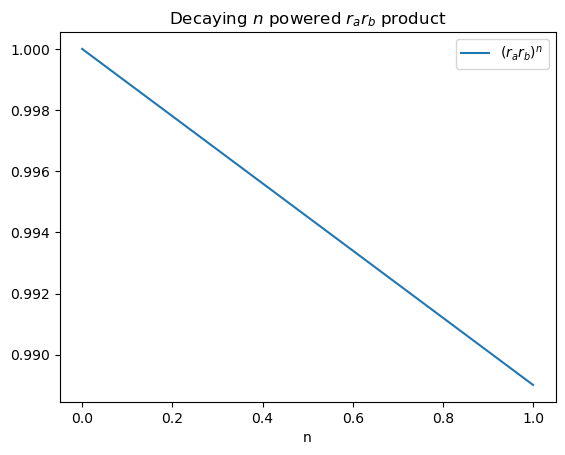

In [185]:
# Free parameter
f_calc = 100.e3

Theta = 1./f_calc
N = int(np.ceil(Theta/(2.*ARM.T)))
recursion_level = int(np.ceil(10.*ARM.tau()/Theta))

print("Theta: {0:.2e} [s]".format(Theta))
print("N: {0}".format(N))
print("Recursion level: {0}".format(recursion_level))

n = np.arange(0, N+1, 1)
rarbn = np.power(ARM.r_a*ARM.r_b, n)

plt.plot(rarbn, label="$(r_a r_b)^n$")
plt.title("Decaying $n$ powered $r_a r_b$ product")
plt.xlabel("n")
plt.legend()

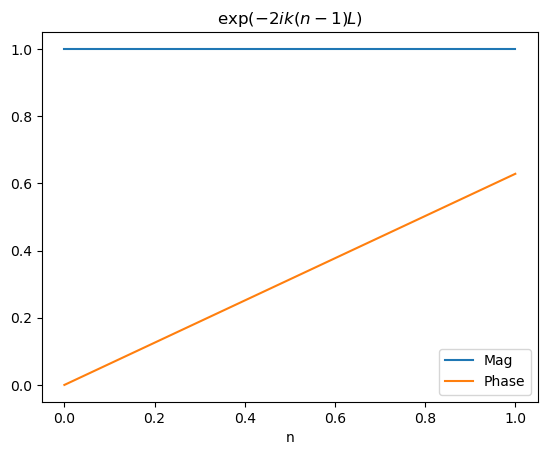

In [186]:
e2iknL = np.exp(-2.j*k*(n)*ARM.L)  # Convert to the case when: L is multiple of lambd

plt.plot(np.abs(e2iknL), label="Mag")
plt.plot(np.angle(e2iknL), label="Phase")

plt.title("$\exp(-2ik(n-1)L)$")
plt.xlabel("n")
plt.legend()

In [187]:
r_level = recursion_level
N_max = N

#E_past = np.zeros(r_level)

E_last = 0.j
d_zeta = v*2.*ARM.T
Ze = 0.

def E_i(cavity, N=0):
    global N_max, E_last, Ze

    Sum = 0.
    
    if N == 0:
        N = N_max
    
    k2j = -2.j*k
    
    for idx in np.arange(1, N+1, 1):
        #print(idx)
        Sum = Sum + rarbn[idx] * e2iknL[idx] * np.exp(k2j*Ze) * E_in(2.*idx*cavity.T)
        Ze = Ze + d_zeta
        
    res = cavity.t_a * Sum + rarbn[N] * e2iknL[N] * np.exp(k2j*Ze) * E_last
    E_last = res
    return res

In [188]:
2*N*ARM.T

2.001384571735157e-05

In [189]:
E_i(ARM, N_max)

(0.0008001265856321357+0.0005813245453829216j)

In [190]:
def time_window(v, cavity, FSR=2.):
    t_stop = (FSR/2.) * lambd/v
    print(t_stop)
    number_of_points = int(np.ceil(t_stop/Theta))
    print(number_of_points)
    return number_of_points, np.linspace(0., t_stop, number_of_points)

#number_of_points, tdata = time_window(v, ARM)


## Definition of useful arrays

In [191]:
points, tdata = time_window(v, ARM, FSR=0.2)
ein = np.zeros(points, dtype=np.complex128)
res = np.zeros(points, dtype=np.complex128)
Adata = np.zeros(points)

1.0241311464795526
102414


## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [192]:
def d2(t,v, type):
    if type=="const":
        return 2
    if type=="linear":
        return v*t + L
    if type=="sin":
        A = 1.e-7
        f = 200.e6  # Hz
        return A*np.sin(2.*np.pi*f*t)

In [193]:

def simulation_check(v, type_d):


    points, tdata = time_window(v, ARM, FSR=0.2)
    
    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = E_i(ARM, N=N_max)
        Adata[idx] = Airy(ARM.F(), (t*k*v))

    plt.figure()
    plt.plot(tdata, np.abs(res)**2/ARM.gain(), label="Numerical magn")
    plt.plot(tdata, np.roll(Adata, 170)*ARM.gain(), label="Airy")
    #plt.xlim(-0.01,0.07)
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.angle(res,deg=True), label="Numerical phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

If you want to keep your original phase with pi-periodicity, you should first double the phase, unwrap it, then divide it by two.

1.0241311464795526
102414


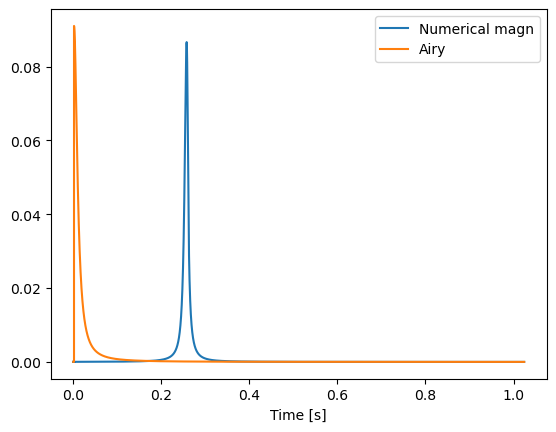

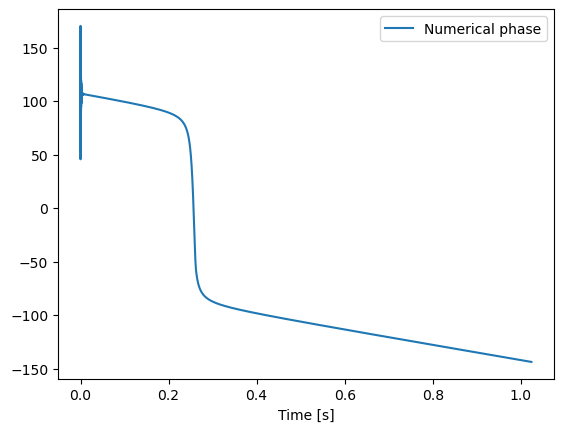

In [194]:
Ze = 0.
simulation_check(v, "linear" )

# TODO:
    1. Delay factor (0.013 in Adata)
    2. Reproduce FigureFigure2.5 (Rakhmanov)

## Delay factor
The delay factor is 0.2867895 but, in order to have a better match between Airy data and numerical values, it is possibile to compute it taking the instants in which we have the maximum value from Airy data and numerical solution and then effectuate the difference. Moreover in the function `simulation_check` we add the factor 0.2867895 to $k*t$ instead of just $t$. Here the delay factor that will be calculated has to be added to $t$ to have a perfect match.

In [195]:
np.max(abs(res)**2/ARM.gain())

0.08661318560366867

In [196]:
np.max(Adata*ARM.gain())

0.0909918107370332

In [197]:

t_E=0
t_A=0
for idx, t in enumerate(tdata):
    if abs(res[idx])**2/ARM.gain() == 0.08661318560366867:
        t_E=t
    if Adata[idx]*ARM.gain() == 0.0909918107370332:
        t_A=t

In [198]:
print(t_E)

0.25746028821792705


In [199]:
print(t_A)

0.0


In [200]:
delay=t_A-t_E
print(delay)

-0.25746028821792705


In [201]:

def simulation_check(v, cav):


    points, tdata = time_window(v, cav, FSR=0.2)
    
    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = E_i(cav, N=N_max)
        Adata[idx] = Airy(cav.F(), ((t+delay)*k*v))

    plt.figure()
    plt.plot(tdata, np.abs(res)**2/cav.gain(), label="Numerical magn")
    plt.plot(tdata, Adata*cav.gain(), label="Airy")
    #plt.xlim(-0.01,0.07)
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.angle(res,deg=True), label="Numerical phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

1.0241311464795526
102414


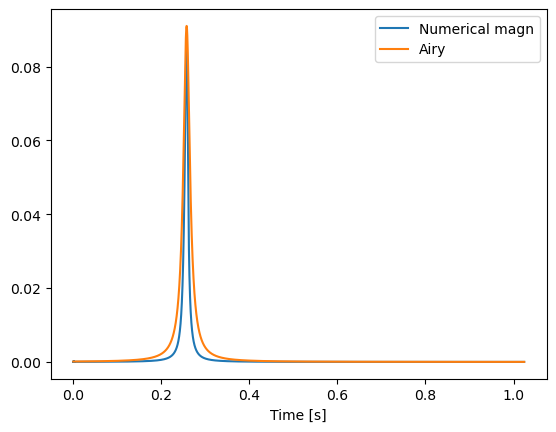

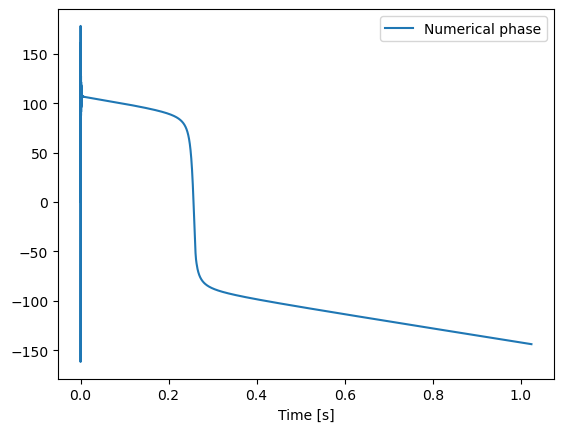

In [202]:
Ze=0.
simulation_check(v, ARM)

## Implementation of Eq 2.69

$\LARGE E(t) \approx D_0 e^{-\frac{t}{\tau} - i\frac{kv}{2T} t^2} + \frac{t_a A}{1-r_a r_b e^{-2ikvt}}$

where:

$\LARGE D_0 = t_a A \sqrt{\frac{i \pi}{2kvT}} e^{\frac{iT}{2kv\tau^2}}$

$\tau$ is the storage time

$k$ is the wave number

$v$ is the mirror velocity

$T$ is half of the round-trip time

In [203]:
# Free parameter
f_calc = 100.e3

Theta = 1./f_calc
N = int(np.ceil(Theta/(2.*ARM.T)))
recursion_level = int(np.ceil(10.*ARM.tau()/Theta))

print("Theta: {0:.2e} [s]".format(Theta))
print("N: {0}".format(N))
print("Recursion level: {0}".format(recursion_level))

n = np.arange(0, N+1, 1)
rarbn = np.power(ARM.r_a*ARM.r_b, n)

Theta: 1.00e-05 [s]
N: 1
Recursion level: 1802


In [204]:
e2iknL = np.exp(-2.j*k*(n)*ARM.L) 

In [205]:
r_level = recursion_level
N_max = N

#E_past = np.zeros(r_level)

E_last = 0.j
d_zeta = v_cr(ARM)*2.*ARM.T
Ze = 0.

def E_i(cavity, N=0):
    global N_max, E_last, Ze

    Sum = 0.
    
    if N == 0:
        N = N_max
    
    k2j = -2.j*k
    
    for idx in np.arange(1, N+1, 1):
        #print(idx)
        Sum = Sum + rarbn[idx] * e2iknL[idx] * np.exp(k2j*Ze) * E_in(2.*idx*cavity.T)
        Ze = Ze + d_zeta
        
    res = cavity.t_a * Sum + rarbn[N] * e2iknL[N] * np.exp(k2j*Ze) * E_last
    E_last = res
    return res

In [206]:
def time_window(v, cavity, FSR=2.):
    t_stop = (FSR/2.) * lambd/v
    print(t_stop)
    number_of_points = int(np.ceil(t_stop/Theta))
    print(number_of_points)
    return number_of_points, np.linspace(0., t_stop, number_of_points)

In [207]:
def D_0(Ein, V,cav):
    return cav.t_a*Ein*np.sqrt(1.j*np.pi/(2.*k*V*cav.T))*np.exp(1.j*cav.T/(2.*k*V*np.power(cav.tau(),2)))

In [208]:
def E_cr(t, Ein, V, cav):
    doppler = D_0(Ein, V, cav)*np.exp(-t/cav.tau() - 1.j*k*V*np.power(t,2)/(2.*cav.T))
    adiab = cav.t_a*Ein/(1.-cav.r_a*cav.r_b*np.exp(-2.j*k*V*t))
    return doppler, adiab

## Check if the numerical simulation is computed correctly and it reproduces the cavity ringing.

In [209]:
points, td = time_window(v_cr(ARM), ARM, FSR=0.2)

dyn = np.zeros(points, dtype=np.complex128)
res_dyn = np.zeros(points, dtype=np.complex128)

ad = np.zeros(points, dtype=np.complex128)
do = np.zeros(points, dtype=np.complex128)

0.10241311464795526
10242


In [210]:

def simulation_check_dyn(v, cav):


    points, tdata = time_window(v_cr(cav), cav, FSR=0.2)
    
    for idx, t in enumerate(tdata):
        ad[idx], do[idx] = E_cr(t, E_in_avg, v, cav)
        res_dyn[idx] = E_i(cav, N_max)
        dyn[idx]=ad[idx] + do[idx]
    
    
    plt.figure()
    plt.plot(tdata, np.roll(abs(res_dyn)**2/(cav.gain()),100), label="Numerical magn")
    #plt.plot(tdata, abs(dyn)**2/(cav.gain()), label="Lenght scan transient")
    plt.xlabel("Time [s]")
    plt.ylim(0.,0.02)
    plt.xlim(0.,0.02)
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(res_dyn, deg=True)*2)/2, label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(dyn, deg=True)*2)/2, label="Analytical phase")
    plt.xlabel("Time [s]")
    #plt.ylim(0.,0.02)
    plt.xlim(0.,0.1)
    plt.legend()

    return plt.show()

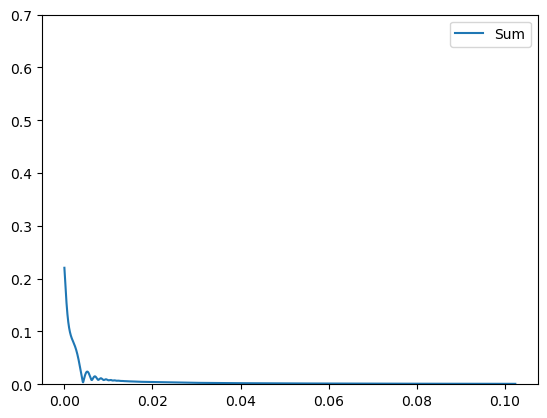

In [211]:


ad, do = E_cr(td, E_in_avg, v_cr(ARM), ARM)
#plt.plot(td, np.abs(ad), label="Adiabatic")
#plt.plot(td, np.abs(do), label="Doppler")
plt.plot(td, abs(ad+do), label="Sum")
roll_factor = 171
res_rolled = np.roll(abs(res_dyn)**2, roll_factor)
#plt.plot(td, res_rolled, label="Numerical")
plt.ylim([0., 0.7])
plt.legend()

0.10241311464795526
10242


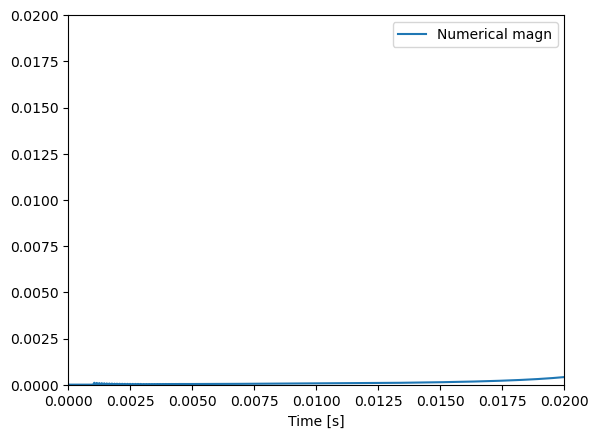

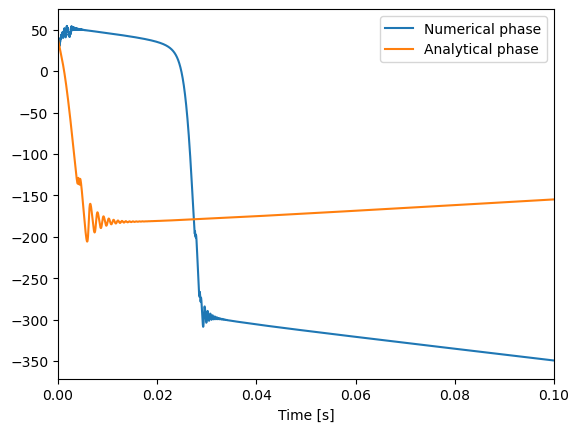

In [212]:
Ze=0.
simulation_check_dyn(v_cr(ARM), ARM)

IndexError: list index out of range

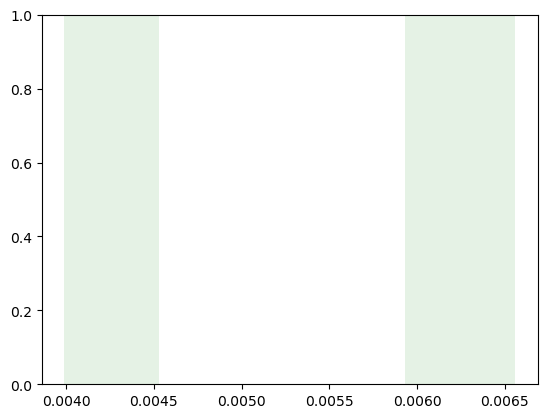

In [213]:
epsilon = 0.012

l = len(td)
diffr = np.zeros(l)
good_times_start = []
good_times_stops = []

last_i_start = 0
last_i_stops = 0
for i in range(l):
    diffr[i] = res_rolled[i] - np.abs(ad+do)[i]
    if abs(diffr[i]) < epsilon:
        if last_i_start + 1 != i:
            good_times_start.append(tdata[i])
            #print(tdata[i])
            
        last_i_start = i

    if abs(diffr[i]) > epsilon:
        if last_i_stops + 1 != i:
            good_times_stops.append(tdata[i])
            #print(tdata[i])
            
        last_i_stops = i

for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)

plt.plot(tdata, diffr)
plt.xlim([0., td[-1]])
plt.ylim([-.05, .05])

In [ ]:
plt.plot(td, np.abs(ad+do), label="Sum")
plt.plot(td, res_rolled, label="Numerical")
plt.ylim([0., 0.6])
for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()

print("Good approximation starts after: " + str(good_times_start[0]))
print(T/good_times_start[0])      # ~0.07 T
print(tau()/good_times_start[0])  # ~0.63 tau

In [ ]:

E_cr(time_window(v_cr()/10, 1000), ein, v_cr()/10)

In [ ]:
vel = [v_cr()/10, v_cr(), v_cr()*10]
res_scan = {}
for i, j in zip([0,1,2], vel):
    res_scan[i] = E_cr(time_window(j, 1000), ein, j)

plt.figure()
plt.plot(time_window(v_cr()/10, number_of_points), -E_cr(time_window(v_cr()/10, 1000), ein, v_cr()/10).imag, label="v/v_cr {0:.6f}".format(0))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr(), number_of_points), -E_cr(time_window(v_cr(), 1000), ein, v_cr()).imag, label="v/v_cr {0:.6f}".format(1))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()*10, number_of_points), -E_cr(time_window(v_cr()*10, 1000), ein, v_cr()*10).imag, label="v/v_cr {0:.6f}".format(2))
plt.legend()

plt.show()

## Figure 2.6 but with the imaginary part of the numerical solution

In [ ]:
plt.figure()
plt.plot(time_window(v_cr()/10, number_of_points), -E(time_window(v_cr()/10, 1000), v_cr()/10, "linear").imag, label="v/v_cr {0:.6f}".format(0))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr(), number_of_points), -E(time_window(v_cr(), 1000), v_cr(), "linear").imag, label="v/v_cr {0:.6f}".format(1))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()*10, number_of_points), -E(time_window(v_cr()*10, 1000), v_cr()*10, "linear").imag, label="v/v_cr {0:.6f}".format(2))
plt.legend()

plt.show()

In [ ]:
def simulation_check_dyn(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)
    tdata1=time_window(v*20, number_of_points)
    
    for idx, t in enumerate(tdata1):
        dyn[idx] = E_cr(t, ein[idx], v*20)

    for idx, t in enumerate(tdata):
        res_dyn[idx] = E(t, v, type_d, N=25)
    
    
    
    plt.figure()
    plt.plot(tdata, abs(res_dyn)**2/gain(), label="Numerical magn")
    plt.plot(tdata, abs(dyn)**2/gain(), label="Lenght scan transient")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(res_dyn, deg=True)*2)/2, label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(dyn, deg=True)*2)/2, label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

In [ ]:
simulation_check_dyn(v_cr(), 1000, "linear")

In [ ]:
plt.plot(time_window(v_cr(), number_of_points), abs(res_scan[1])**2/gain(), label="v/v_cr {0:.5f}".format(j))
#plt.plot(time_window(v_cr(), number_of_points), abs((res**2)/gain()), label = "numerical solution")
plt.legend()

## Figure 2.6 $\frac{v}{v_{cr}} = 0.1$

In [ ]:
plt.plot(time_window(v_cr()/10, number_of_points),-res_scan[0].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 1$

In [ ]:
plt.plot(time_window(v_cr(), 1000), -res_scan[1].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 10$

In [ ]:
plt.plot(time_window(v_cr()*10, 1000), -res_scan[2].imag)

# Pound-Drever-Hall

In [ ]:
plt.plot(time_window(v, 1000), res.imag)

In [ ]:
gamma = np.pi/2
def V_pdh(gamma,res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v, 1000), V_pdh(i, res), label="phase: {0:.2f}".format(i))

plt.legend()

In [ ]:
def V_pdh_scan(gamma, res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

In [ ]:
for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v_cr(), 1000), V_pdh_scan(i, res_dyn), label="phase: {0:.2f}".format(i))
    plt.plot(time_window(v_cr(), 1000), V_pdh_scan(i,res_scan[1]),'--', label="phase: {0:.2f}".format(i))
plt.legend()

## Adjusted Pound-Drever signal Eq 2.85

In [ ]:
def V_pdh_D(t, v, Ein, gamma):
    t_0=v*lambd/2
    return - Ein*np.abs(D_0(Ein, v))**2*np.exp(t-t_0/tau())*np.sin(gamma+np.angle(D_0(Ein,v))-k*v*(t-t_0)**2/2*T)

In [ ]:
def x_a(t):
    return 0.0

In [ ]:
def E_ref(t, Edt):
    return np.exp(-2.j*k*x_a(t)) * ((r_a**2 + t_a**2)*E_in(t) - t_a * Edt) / r_a #Eq 1.48

tdata = time_window(v, number_of_points)

for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t,v,"linear", N=25)
    eref[idx] = E_ref(t, res[idx])

R_coeff = eref/ein

In [ ]:
plt.figure()
plt.plot(tdata,np.abs(R_coeff), label="Reflected power")
plt.legend()
plt.figure()
plt.plot(tdata,np.unwrap(np.angle(R_coeff,deg=True)*2)/2, label="Reflected phase",color="orange")
plt.legend()
plt.show()

## Reflected field for scan transient with critical velocity

In [ ]:
res_scan_dyn = np.zeros(number_of_points, dtype = np.complex_)
eref_scan = np.zeros(number_of_points, dtype = np.complex_)
res_dyn = E(time_window(v_cr(), 1000), v_cr(), "linear", N=25)

for idx, t in enumerate(time_window(v_cr(), 1000)):
    res_scan_dyn[idx] = E_cr(t, ein[idx], v_cr())
    eref_scan[idx] = E_ref(t, res_dyn[idx])
R_coeff_scan = eref_scan/ein

In [ ]:
plt.figure()
plt.plot(np.abs(R_coeff_scan), label="Reflected power")
plt.legend()

plt.figure()
plt.plot(np.angle(R_coeff_scan), label="Reflected phase",color="orange")
plt.legend()

plt.show()

# TODO:
    1. Confrontare Reflected power to model in Finesse